In [1]:
import os

GPU_NUM = 1
GPU_NUM = str(GPU_NUM)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_NUM 

# torch를 CUDA_VISIBLE_DEVICES 뒤에 import 해야 제대로 설정됨.
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'CUDA Device Name: {torch.cuda.get_device_name(0)}, GPU NUM: {GPU_NUM}')
else: print(device)

torch.cuda.empty_cache() 

CUDA Device Name: NVIDIA GeForce RTX 4090, GPU NUM: 1


In [20]:
import warnings
warnings.filterwarnings('ignore')

import h5py
import scipy
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import HTML
from scipy.signal import hilbert
from dataclasses import dataclass
from matplotlib.animation import FuncAnimation

import torch
import torch.nn.functional as F

In [3]:
from utils.utils import *

allocate_dummy_gpu_memory(10)

Allocated dummy GPU memory: 10240.00 MiB


In [4]:
def resample_cols(x, W_p):
    B, C, D, W = x.shape

    x = x.permute(0, 2, 1, 3).reshape(B * D, C, W)  # (B*D, C, W)
    x = F.interpolate(x, size=W_p, mode='linear', align_corners=False)
    x = x.reshape(B, D, C, W_p).permute(0, 2, 1, 3) # (B, C, D, W_p)

    return x

In [5]:
class DAS():
    def __init__(self, H_p: int=374, W_p: int=128, N: int=128, H_m: float=0.038, W_m: float=0.038,
                 sos: float=1540., freq: float=7.6e6, sampling: float=4.1118):
        self.N      = N
        self.H_p    = H_p
        self.W_p    = W_p
        self.H_m    = H_m
        self.W_m    = W_m
        self.sos    = sos
        self.freq   = freq
        self.sampling = sampling

        # Scale factors
        self.p2m_H  = H_m / H_p
        self.p2m_W  = W_m / W_p
        self.m2l    = freq / sos
        self.l2s    = sampling

        x = torch.arange(H_p).view(-1, 1, 1) * self.p2m_H   # (H_p, 1, 1)
        y = torch.arange(W_p).view(1, -1, 1) * self.p2m_W   # (1, W_p, 1)
        n = torch.arange(N).view(1, 1, -1) * self.p2m_W     # (1, 1, N)

        M1 = x * (self.m2l * self.l2s)                              # (H_p, 1, 1)
        M2 = torch.sqrt((y - n)**2 + x**2) * (self.m2l * self.l2s)  # (H_p, W_p, N)
        M  = M1 + M2                                                # (H_p, W_p, N)

        self.M1 = torch.round(M1).long()
        self.M2 = torch.round(M2).long()
        self.M  = torch.round(M).long()
        print(f'{"Indexing Matrix":<25}: {self.M.shape}')

        self.idx_x = torch.arange(H_p).long()
        self.idx_y = torch.arange(W_p).long()
        self.idx_n = torch.arange(N).long()

        # Resampler
        if W_p != 128:
            self.resampler = resample_cols
            self.W_p = W_p
        
        else:
            self.resampler = None

        # Dynami Aperture
        list_sigma  = torch.linspace(0.01, 1, H_p)**0.3
        list_sigma  = list_sigma * 5 + 1
        list_s      = [-s for s in range(0, N)]

        x = torch.stack([torch.linspace(s, s + N - 1, N) for s in list_s])
        self.mask_DA = torch.stack([torch.exp(-0.5 * (x / sigma)**2) for sigma in list_sigma]).unsqueeze(0).unsqueeze(0) # (1, 1, H_p, N, N)

    def delay_and_sum(self, 
                        RF: torch.Tensor | np.ndarray,
                        Ne: int | None=None,
                        Nf: int | None=None,
                        ensemble: bool=True, PA: bool=False, DA: bool=True):
        
        if not isinstance(RF, torch.Tensor):
            RF = torch.tensor(RF, dtype=torch.float32)
        
        elif RF.dtype != torch.float32:
            RF = RF.to(dtype=torch.float32)

        if self.resampler is not None:
            print(f'{"Resampling RF Columns":<25}: {RF.shape[-1]} -> {self.W_p}')
            RF = self.resampler(RF, self.W_p)

        print(f'{"RF(Raw)":<25}: {RF.shape}')
        if Ne is not None:
            RF = RF[Ne, :, :, :]
        
        if Nf is not None:
            RF = RF[:, Nf, :, :]
        print(f'{"RF(Target)":<25}: {RF.shape}')
        
        # Index clamping
        M_idx   = self.M2 if PA else self.M
        M_idx   = M_idx.clamp(0, RF.shape[-2] - 1)

        RF_res  = RF[:, :, M_idx, self.idx_n]
        print(f'{"Extracted":<25}: {RF_res.shape}')

        if DA is not False:
            RF_res = RF_res * self.mask_DA.to(RF_res.device)
            print(f'{"Dynamic Aperture mask":<25}: {self.mask_DA.shape}')

        RF_res = RF_res.sum(dim=-1).float()
        print(f'{"RF Result":<25}: {RF_res.shape}')

        if ensemble is not False:
            RF_res = RF_res.mean(dim=0)
            print(f'{"RF Result(AGG)":<25}: {RF_res.shape}')
        
        print('--' * 25)

        return RF_res

In [6]:
@dataclass
class Config:
    H: int = 256
    W: int = 256
    N: int = 256
    
    an: int = 31
    depth:  float = 0.038
    width:  float = 0.038
    p2m_H:  float = depth / H
    p2m_W:  float = width / W
    m2l:    float = 7.6e6 / 1540.
    l2s:    float = 4.1118

    def __repr__(self):
        items = [f"    {k:<10}: {v}" for k, v in self.__dict__.items()]
        return f"{'-'*15} Config {'-'*15}\n\n" + ",\n".join(items)

cfg = Config()
print(cfg)

--------------- Config ---------------

    H         : 256,
    W         : 256,
    N         : 256,
    an        : 31,
    depth     : 0.038,
    width     : 0.038,
    p2m_H     : 0.0001484375,
    p2m_W     : 0.0001484375,
    m2l       : 4935.064935064935,
    l2s       : 4.1118


In [46]:
DATASET_PATH = Path('/nas/Guhong/US_Data/Dataset/Dataset_ATS539/RF')
print(f'Data Path: {DATASET_PATH}\n')

DATA_LIST = listdir(DATASET_PATH)
print(f'Data Folders: {len(DATA_LIST)} folders found')
for folder in DATA_LIST:
    folder_path = DATASET_PATH / folder
    file_count = len(list(folder_path.glob('*')))
    print(f"- {folder}: {file_count} files")

Data Path: /nas/Guhong/US_Data/Dataset/Dataset_ATS539/RF

Data Folders: 6 folders found
- Phantom_UL_01_R.h5: 0 files
- Phantom_UL_02_R.h5: 0 files
- Phantom_UL_03_R.h5: 0 files
- Phantom_UT_01_R.h5: 0 files
- Phantom_UT_02_R.h5: 0 files
- Phantom_UT_03_R.h5: 0 files


In [50]:
print(f'{"Sample Data":<20}: {DATA_LIST[0]}')

DATA_PATH = DATASET_PATH / DATA_LIST[0]
print(f'{"Sample Data Path":<20}: {DATA_PATH}')

# RF_LIST = list(DATA_PATH.glob('*an31_F_*'))
# print(f'\n{" RF Files ":-^30}\n- {"\n- ".join(RF.name for RF in RF_LIST)}')

# PB_LIST = list(DATA_PATH.glob('*an31_B_*'))
# print(f'\n{" PB Files ":-^30}\n- {"\n- ".join(PB.name for PB in PB_LIST)}')

# RB_LIST = list(DATA_PATH.glob('*an31_R_*'))
# print(f'\n{" RB Files ":-^30}\n- {"\n- ".join(RB.name for RB in RB_LIST)}')

Sample Data         : Phantom_UL_01_R.h5
Sample Data Path    : /nas/Guhong/US_Data/Dataset/Dataset_ATS539/RF/Phantom_UL_01_R.h5


In [54]:
p = 0
# PB_DATA = h5py.File(PB_LIST[p], 'r')
# print(f'PB Data Keys: {list(PB_DATA.keys())}')
# PB = PB_DATA['imgs'][:]
# print(f'PB Shape: {PB.shape}')

# RB_DATA = h5py.File(RB_LIST[p], 'r')
# print(f'\nRB Data Keys: {list(RB_DATA.keys())}')
# RB = RB_DATA['imgs'][:]
# print(f'RB Shape: {RB.shape}')

# RF_DATA = h5py.File(RF_LIST[p], 'r')
# print(f'\nRF Data Keys: {list(RF_DATA.keys())}')

RF_DATA = h5py.File(DATA_PATH, 'r')
print(f'\nRF Data Keys: {list(RF_DATA.keys())}')

RF_O    = torch.tensor(RF_DATA['rf'][:], dtype=torch.float32)
print(f'RF Shape: {RF_O.shape}')
# B, T, C = RF_O.shape
# RF_B    = RF_O.reshape(cfg.an, B, T // cfg.an, C)
RF_B = RF_O
print(f'RF Shape: {RF_O.shape} -> {RF_B.shape}')
print(f'RF Min: {RF_B.min():.4f}, Max: {RF_B.max():.4f}, Mean: {RF_B.mean():.4f}, Std: {RF_B.std():.4f}')


RF Data Keys: ['rf']
RF Shape: torch.Size([1000, 1, 2304, 128])
RF Shape: torch.Size([1000, 1, 2304, 128]) -> torch.Size([1000, 1, 2304, 128])
RF Min: -16384.0000, Max: 16384.0000, Mean: -1.1738, Std: 1286.0500


#### **h5 to png**
import h5py
import numpy as np
import cv2
import os

save_dir = 'png_output'
os.makedirs(save_dir, exist_ok=True)

for bmode in PB_LIST:
    bmode_name = bmode.name.split('.')[0]
    os.makedirs(f'{save_dir}/{bmode_name}', exist_ok=True)
    with h5py.File(bmode, 'r') as f:
        data = f['imgs'][:]

    fs = [0, 25, 50, 75, 100]
    frames = [data[f] for f in fs]
    for i, img in enumerate(frames):

        img = np.asarray(img, dtype=np.float32)

        # normalizatione
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # uint8
        img_uint8 = (img * 255).clip(0, 255).astype(np.uint8)

        cv2.imwrite(f'{save_dir}/{bmode_name}/frame_{fs[i]:04d}.png', img_uint8)

In [30]:
SAMPLE_DATA = scipy.io.loadmat('data_sample.mat')
print(f'\nSample Data Keys: {list(SAMPLE_DATA.keys())}')

SAMPLE_RF = SAMPLE_DATA['RF_data']
print(f'\nSample Data Shape: {SAMPLE_RF.shape}')


Sample Data Keys: ['__header__', '__version__', '__globals__', 'RF_data']

Sample Data Shape: (1, 100, 2176, 128)


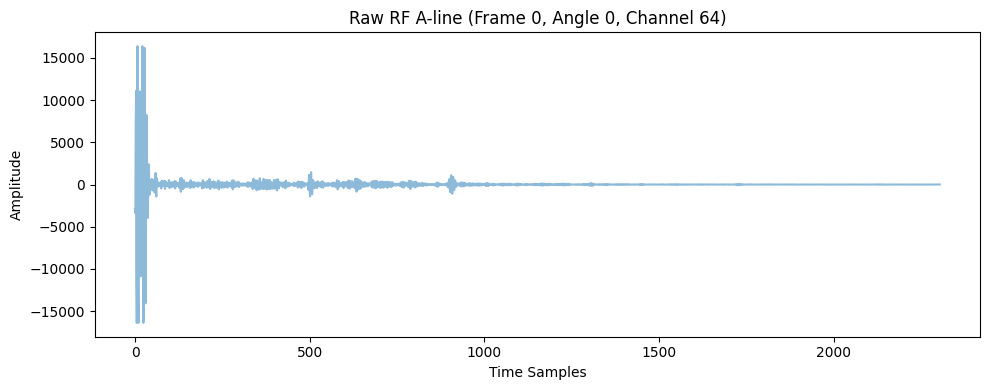

In [55]:
frame   = 0
angle   = 0
elem    = 64

plt.figure(figsize=(10,4))
rf_line = RF_B[angle, frame, :, elem]

plt.plot(rf_line, alpha=0.5)
plt.title(f'Raw RF A-line (Frame {frame}, Angle {angle}, Channel {elem})')
plt.xlabel('Time Samples')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

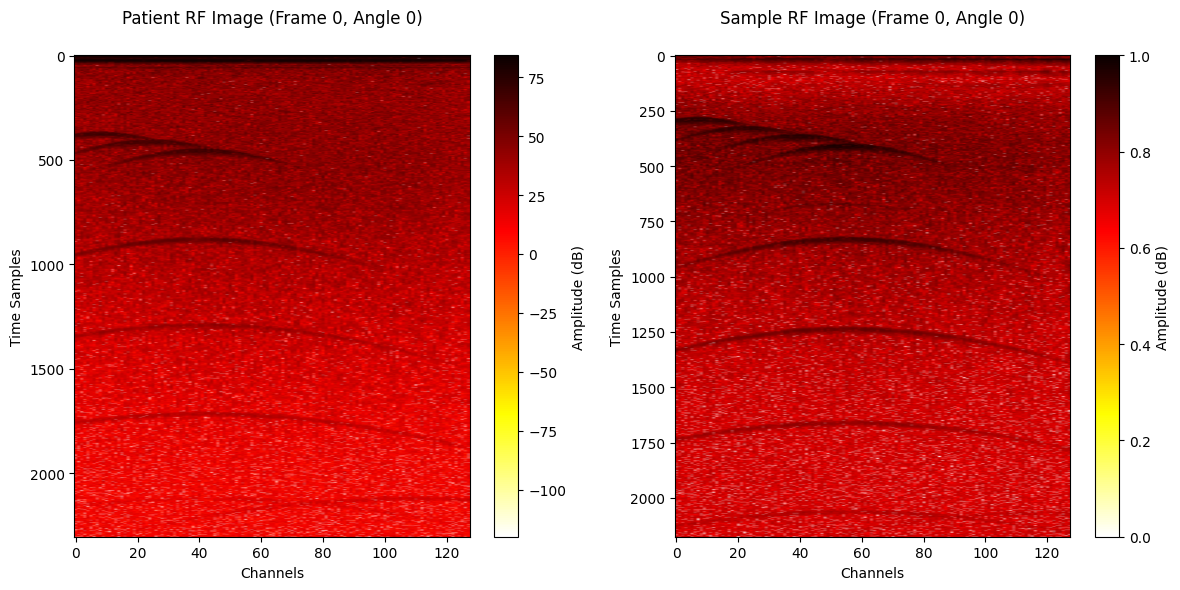

In [57]:
frame = 0
angle = 0
rf_img = RF_B[angle, frame]
rf_img = np.abs(rf_img)
rf_img = 20 * np.log10(rf_img + 1e-6)
# rf_img = (rf_img - rf_img.min()) / (rf_img.max() - rf_img.min())

sf_img = SAMPLE_RF[angle, frame]
sf_img = np.abs(sf_img)
sf_img = 20 * np.log10(sf_img + 1e-6)
sf_img = (sf_img - sf_img.min()) / (sf_img.max() - sf_img.min())

imgs = [rf_img, sf_img]
titles = ['Patient RF Image', 'Sample RF Image']

plt.figure(figsize=(12, 6))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i + 1)
    plt.imshow(img, cmap='hot_r', aspect='auto')
    plt.title(f'{titles[i]} (Frame {frame}, Angle {angle})', y=1.05)
    plt.xlabel('Channels')
    plt.ylabel('Time Samples')
    plt.colorbar(label='Amplitude (dB)')

plt.tight_layout()
plt.show()

# plt.figure(figsize=(4, 6))
# plt.imshow(rf_img, cmap='hot_r', aspect='auto')
# plt.title(f'Raw RF Data (Frame {frame}, Angle {angle})', y=1.05)
# plt.xlabel('Channels')
# plt.ylabel('Time Samples')
# plt.colorbar(label='Amplitude (dB)')
# plt.tight_layout()
# plt.show()

In [58]:
release_dummy_gpu_memory()

Released dummy GPU memory. 0.00 MiB allocated, 0.00 MiB reserved


In [61]:
das = DAS(H_p=cfg.H, W_p=cfg.W, N=cfg.N)

frames = []
# for frame in range(RF_B.shape[1]):
for frame in range(1):
    result = das.delay_and_sum(RF_B[100:, frame:frame+1, :, :])
    frames.append(result[0])

print(f'Processed {len(frames)} frames with DAS.')

Indexing Matrix          : torch.Size([256, 256, 256])
Resampling RF Columns    : 128 -> 256
RF(Raw)                  : torch.Size([900, 1, 2304, 256])
RF(Target)               : torch.Size([900, 1, 2304, 256])
Extracted                : torch.Size([900, 1, 256, 256, 256])
Dynamic Aperture mask    : torch.Size([1, 1, 256, 256, 256])
RF Result                : torch.Size([900, 1, 256, 256])
RF Result(AGG)           : torch.Size([1, 256, 256])
--------------------------------------------------
Processed 1 frames with DAS.


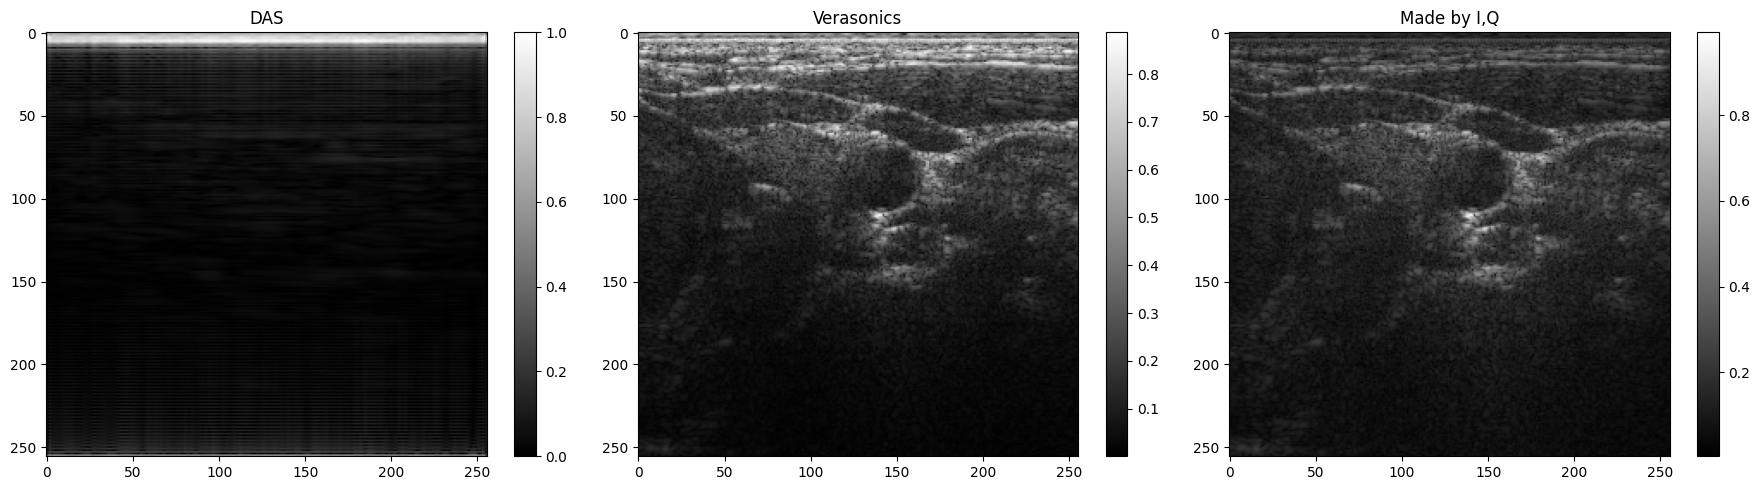

In [62]:
frame = 0
d_img = frames[frame]
# d_img = np.abs(d_img)
d_img = np.abs(hilbert(d_img, axis=0))
d_img = 20 * np.log10(d_img + 1e-6)
d_img = (d_img - d_img.min()) / (d_img.max() - d_img.min())
d_img = d_img**4.5

b_img = PB[frame]
r_img = RB[frame]

imgs = [d_img, b_img, r_img]
titles = ['DAS', 'Verasonics', 'Made by I,Q']

plt.figure(figsize=(18, 5))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img, aspect='auto', cmap='gray')
    plt.title(titles[i])
    plt.colorbar()

plt.tight_layout()
plt.show()

In [36]:
def animate_sample(frame_data):
    fs = len(frame_data)

    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(frame_data[0], cmap='gray')

    def update(frame):
        im.set_data(frame_data[frame])

        fig.suptitle(f'Frame: {frame+1}/{fs}', fontsize=16)
        return im

    ani = FuncAnimation(fig, update, frames=fs, interval=60, blit=False, repeat=True)
    plt.close()
    
    return ani

In [37]:
ani = animate_sample(frames)

In [38]:
HTML(ani.to_jshtml())